# Кратко о решении

Для каждой cookie собираем 118 признаков по её событиям за сутки. Считаем, какие действия совершались, сколько было разных объявлений и запросов, как часто происходили события. Добавляем возраст cookie, платформу, браузер, ОС и статистики координат.

Берём только события внутри `[window_start_ts, window_end_ts)` и удаляем точные дубли. Числовые пропуски заполняем значением -1, а категориальные признаки передаём в CatBoost. Сами ID в модель не попадают: например, по объявлениям считаем их количество и разнообразие. Показы капчи использовать не получилось: все они оказались вне нужных окон.

В конце обучаем три CatBoost и усредняем их вероятности. У всех моделей по 650 деревьев, глубина 5, `learning_rate=0.04` и `l2_leaf_reg=5`. Отличаются только seed: 42, 17 и 2026. Все три модели учатся на полном train. В файл отправляем оценки без порога.

## 1. Загрузка данных

In [1]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

seed = 42
np.random.seed(seed)

catboost_params = dict(
    iterations=650, depth=5, learning_rate=0.04, l2_leaf_reg=5,
    loss_function="Logloss", random_seed=seed, thread_count=1,
    task_type="CPU", verbose=False, allow_writing_files=False,
)
date_columns = ["cookie_created_at", "window_start_ts", "window_end_ts"]
event_types = (
    "search_results_view", "item_view", "photo_swipe", "seller_page_view",
    "contact_chat_open", "contact_phone_show", "contact_message_sent",
    "favorite_add", "login", "captcha_shown",
)
platform_names = {"desktop": "web", "iphone": "ios"}

model_seeds = [42, 17, 2026]

In [2]:
train = pd.read_csv(f"data/train.csv", dtype={"cookie_id": str}, parse_dates=date_columns)
test = pd.read_csv(f"data/test.csv", dtype={"cookie_id": str}, parse_dates=date_columns)
events = pd.read_csv(f"data/events.csv.gz",
    dtype={"cookie_id": str, "item_id": str, "eid": str},
    parse_dates=["event_ts"],
)

train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


Посмотрим на несколько строк из таблицы событий.

In [3]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [4]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Events:", events.shape)
print("Доля ботов в train:", round(train["target"].mean(), 4))

Train: (11091, 5)
Test: (4909, 4)
Events: (328905, 14)
Доля ботов в train: 0.0811


В train 11 091 cookie, в test — 4 909. Ботов в обучающей выборке около 8%.

In [5]:
dates = pd.DataFrame({
    "выборка": ["train", "test"],
    "начало": [train["window_start_ts"].min(), test["window_start_ts"].min()],
    "конец": [train["window_start_ts"].max(), test["window_start_ts"].max()],
})
dates

,выборка,начало,конец
0,train,2026-04-06,2026-04-19
1,test,2026-04-20,2026-04-26


Train заканчивается 19 апреля, а test начинается 20 апреля. Поэтому на валидации тоже будем обучаться на ранних днях и предсказывать для более поздних.

In [6]:
events.isna().mean().sort_values(ascending=False).round(3)

search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
seller_type      0.407
item_id          0.348
item_category    0.100
item_location    0.072
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
dtype: float64

In [7]:
events["platform"].value_counts()

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

В поисковых полях и координатах много пропусков. Эти поля заполняются не для всех событий, поэтому строки с пропусками оставим.

Ещё видно, что одна и та же платформа может быть записана как `WEB`, `Web` или `web`. Приведём такие записи к одному виду.

## 2. Очистка

Добавим к каждому событию начало и конец окна его cookie. Затем оставим только события внутри окна: начало включаем, конец не включаем.

In [8]:
meta = pd.concat([train.drop(columns="target"), test], ignore_index=True)

clean = events.merge(meta[["cookie_id"] + date_columns], on="cookie_id", validate="many_to_one")
inside = (clean["event_ts"] >= clean["window_start_ts"]) & (clean["event_ts"] < clean["window_end_ts"])
report = {"исходных событий": len(clean), "вне окна": int((~inside).sum())}
clean = clean.loc[inside].copy()
report["дублей внутри окна"] = int(clean.duplicated().sum())
clean = clean.drop_duplicates().copy()

print("Вне окна:", report["вне окна"])
print("Дублей внутри окна:", report["дублей внутри окна"])

Вне окна: 40779
Дублей внутри окна: 4293


Удалили 40 779 событий вне окна и 4 293 точных дубля. Теперь приведём строки к одному виду и отсортируем события по времени.

Разные действия с одинаковым временем оставляем: это не обязательно дубли.

In [9]:
clean["platform"] = clean.platform.str.strip().str.lower().replace(platform_names).fillna("unknown")
clean["event_name"] = clean.event_name.fillna("unknown")
for col in ("search_page", "pointer_x", "pointer_y"):
    clean[col] = pd.to_numeric(clean[col], errors="coerce")
clean["search_query"] = clean.search_query.str.strip().str.lower().str.replace(r"\s+", " ", regex=True)
clean.loc[clean.search_query.eq(""), "search_query"] = np.nan
clean = clean.sort_values(["cookie_id", "event_ts"], kind="stable").reset_index(drop=True)
report["после очистки"] = len(clean)

print("Осталось событий:", len(clean))

Осталось событий: 283833


In [10]:
event_counts = pd.DataFrame({
    "до очистки": events["event_name"].value_counts(),
    "после очистки": clean["event_name"].value_counts(),
}).fillna(0).astype(int)
event_counts

,до очистки,после очистки
event_name,,
captcha_shown,7928,0
contact_chat_open,6125,5479
contact_message_sent,3081,2778
contact_phone_show,11316,10145
favorite_add,19049,17012
item_view,120817,106448
login,6267,5579
photo_swipe,36517,32570
search_results_view,100402,88479


После очистки осталось 283 833 события. Все показы капчи оказались за пределами окон, так что в признаках их не будет.

## 3. Признаки

Теперь соберём таблицу с одной строкой на cookie. Разделим признаки на четыре группы: действия, время, данные клиента и последовательности действий.

Чтобы оценить разнообразие значений, будем считать энтропию. Если значение всегда одно, энтропия равна нулю. Если значений несколько и встречаются они примерно одинаково часто, она выше. Ещё напишем функцию, которая выбирает самое частое значение.

In [11]:
def entropy(values):
    # Частоты значений переводим в доли, затем считаем энтропию.
    counts = np.array(list(Counter(values).values()), dtype=float)
    if len(counts) == 0:
        return 0.0
    probabilities = counts / counts.sum()
    return float(-(probabilities * np.log2(probabilities)).sum())


def most_common_value(values):
    if len(values) == 0:
        return "unknown"
    counts = Counter(values)
    max_count = max(counts.values())
    # При равной частоте берём первое значение по алфавиту.
    for value in sorted(counts):
        if counts[value] == max_count:
            return value

### Действия и разнообразие

Начнём с количества и доли каждого действия. Затем посчитаем, сколько было разных объявлений, категорий, городов и запросов. Добавим глубину поиска и число контактных действий на один просмотр.

В цикле берём события одной cookie и складываем её признаки в словарь. Из этих словарей собираем DataFrame.

In [12]:
rows = []
for cookie_id, group in clean.groupby("cookie_id", sort=False):
    n = len(group)
    row = {"cookie_id": cookie_id, "b_n_events": n}
    kinds = group.event_name.to_numpy()
    counts = Counter(kinds)
    for name in event_types:
        row[f"b_count_{name}"] = counts[name]
        row[f"b_share_{name}"] = counts[name] / n
    row["b_event_entropy"] = entropy(kinds)
    row["b_event_nunique"] = len(counts)
    for col in ("item_id", "item_category", "item_location", "seller_type", "search_query"):
        values = group[col].dropna().tolist()
        freq = Counter(values)
        row[f"b_{col}_nunique"] = len(freq)
        row[f"b_{col}_unique_ratio"] = len(freq) / len(values) if values else np.nan
        row[f"b_{col}_entropy"] = entropy(values)
        row[f"b_{col}_top_share"] = max(freq.values()) / len(values) if values else np.nan
        row[f"b_{col}_missing_share"] = 1 - len(values) / n
    views = counts["item_view"]
    for name in ("photo_swipe", "favorite_add", "seller_page_view", "contact_phone_show",
                 "contact_chat_open", "contact_message_sent"):
        row[f"b_{name}_per_view"] = counts[name] / max(views, 1)
    for seller in ("private", "pro"):
        row[f"b_seller_{seller}_share"] = float(group.seller_type.eq(seller).mean())
    pages = group.search_page.dropna().to_numpy()
    if len(pages) > 0:
        row["b_search_page_mean"] = float(np.mean(pages))
        row["b_search_page_max"] = float(np.max(pages))
        row["b_search_page_std"] = float(np.std(pages))
    else:
        row["b_search_page_mean"] = np.nan
        row["b_search_page_max"] = np.nan
        row["b_search_page_std"] = np.nan
    row["b_search_page_nunique"] = len(np.unique(pages))
    row["b_search_deep_share"] = float(np.mean(pages >= 5)) if len(pages) else np.nan
    queries = group.search_query.dropna().drop_duplicates().str.len()
    row["b_query_length_mean"] = float(queries.mean())
    rows.append(row)

behavior = pd.DataFrame(rows).set_index("cookie_id")
behavior.head()

,b_n_events,b_count_search_results_view,b_share_search_results_view,b_count_item_view,b_share_item_view,b_count_photo_swipe,b_share_photo_swipe,b_count_seller_page_view,b_share_seller_page_view,b_count_contact_chat_open,...,b_contact_chat_open_per_view,b_contact_message_sent_per_view,b_seller_private_share,b_seller_pro_share,b_search_page_mean,b_search_page_max,b_search_page_std,b_search_page_nunique,b_search_deep_share,b_query_length_mean
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_00013fdfa0bd37dd,15,3,0.200000,4,0.266667,3,0.200000,0,0.000000,2,...,0.5,0.0,0.533333,0.133333,2.000000,3.0,0.816497,3,0.000000,14.666667
ck_000c95f1408dcb00,16,3,0.187500,11,0.687500,1,0.062500,1,0.062500,0,...,0.0,0.0,0.687500,0.062500,2.333333,4.0,1.247219,3,0.000000,14.000000
ck_000e8c52636e3bec,34,9,0.264706,11,0.323529,5,0.147059,3,0.088235,0,...,0.0,0.0,0.411765,0.235294,3.777778,12.0,3.325918,6,0.333333,15.500000
ck_0010e31baa4a1fb7,16,4,0.250000,7,0.437500,1,0.062500,1,0.062500,0,...,0.0,0.0,0.437500,0.187500,1.000000,1.0,0.000000,1,0.000000,12.250000
ck_0010ec3874fb5378,74,20,0.270270,25,0.337838,14,0.189189,4,0.054054,0,...,0.0,0.0,0.459459,0.202703,1.800000,6.0,1.166190,4,0.050000,12.000000


Получилась первая таблица признаков. По ней можно судить и об объёме активности, и о её разнообразии. Насколько это помогает отличать ботов, посмотрим на валидации.

### Время между действиями

Посчитаем длительность пауз и их разброс, число активных минут и часов, максимальное количество событий за минуту и число сессий.

Для подсчёта сессий примем простое правило: пауза больше 30 минут означает начало новой сессии.

In [13]:
rows = []
for cookie_id, group in clean.groupby("cookie_id", sort=False):
    n = len(group)
    row = {"cookie_id": cookie_id}
    # Интервалы считаются после сортировки, включая нулевые интервалы.
    sec = group.event_ts.astype("int64").to_numpy() / 1e9
    gaps = np.diff(sec)
    duration = float(sec[-1] - sec[0])
    row["t_duration_sec"] = duration
    row["t_rate_per_active_minute"] = n / max(duration / 60, 1)
    row["t_first_offset_sec"] = (group.event_ts.iloc[0] - group.window_start_ts.iloc[0]).total_seconds()
    row["t_last_to_end_sec"] = (group.window_end_ts.iloc[0] - group.event_ts.iloc[-1]).total_seconds()
    for name, q in (("p10", .1), ("p25", .25), ("median", .5), ("p75", .75), ("p90", .9)):
        row[f"t_gap_{name}"] = float(np.quantile(gaps, q)) if len(gaps) else np.nan
    if len(gaps) > 0:
        row["t_gap_mean"] = float(np.mean(gaps))
        row["t_gap_std"] = float(np.std(gaps))
        row["t_gap_max"] = float(np.max(gaps))
    else:
        row["t_gap_mean"] = np.nan
        row["t_gap_std"] = np.nan
        row["t_gap_max"] = np.nan
    row["t_gap_cv"] = float(np.std(gaps) / max(np.mean(gaps), 1e-6)) if len(gaps) else np.nan
    for limit in (0, 1, 5, 15, 60, 300):
        row[f"t_gap_le_{limit}_share"] = float(np.mean(gaps <= limit)) if len(gaps) else np.nan
    row["t_gap_nunique_ratio"] = len(np.unique(gaps)) / len(gaps) if len(gaps) else np.nan
    row["t_gap_mode_share"] = max(Counter(gaps).values()) / len(gaps) if len(gaps) else np.nan
    minute_counts = Counter(np.floor(sec / 60))
    hour_counts = Counter(group.event_ts.dt.hour.tolist())
    row["t_active_minutes"] = len(minute_counts)
    row["t_active_hours"] = len(hour_counts)
    row["t_max_events_per_minute"] = max(minute_counts.values())
    row["t_top_hour_share"] = max(hour_counts.values()) / n
    row["t_hour_entropy"] = entropy(group.event_ts.dt.hour.tolist())
    row["t_night_share"] = float(group.event_ts.dt.hour.lt(6).mean())
    # Сессия — группа событий с паузами не длиннее 30 минут.
    new_session = gaps > 1800
    sessions = np.concatenate(([0], np.cumsum(new_session)))
    session_counts = np.bincount(sessions)
    row["t_sessions"] = len(session_counts)
    row["t_largest_session_share"] = session_counts.max() / n
    rows.append(row)

timing = pd.DataFrame(rows).set_index("cookie_id")
timing.head()

,t_duration_sec,t_rate_per_active_minute,t_first_offset_sec,t_last_to_end_sec,t_gap_p10,t_gap_p25,t_gap_median,t_gap_p75,t_gap_p90,t_gap_mean,...,t_gap_nunique_ratio,t_gap_mode_share,t_active_minutes,t_active_hours,t_max_events_per_minute,t_top_hour_share,t_hour_entropy,t_night_share,t_sessions,t_largest_session_share
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_00013fdfa0bd37dd,7.650,15.0,67276.0,11474.0,0.0013,0.0080,0.1485,0.27175,1.9723,0.546429,...,1.000000,0.071429,1,3,15,0.733333,1.052982,0.000000,1,1.0
ck_000c95f1408dcb00,30.117,16.0,53394.0,2889.0,0.0188,0.0245,0.0580,3.74150,7.3168,2.007800,...,1.000000,0.066667,1,6,16,0.437500,2.224602,0.000000,1,1.0
ck_000e8c52636e3bec,6.681,34.0,23160.0,56559.0,0.0024,0.0120,0.0230,0.04900,0.0640,0.202455,...,0.909091,0.060606,1,3,34,0.441176,1.404912,0.000000,1,1.0
ck_0010e31baa4a1fb7,42.376,16.0,42798.0,1226.0,0.0244,0.0760,0.3340,5.57700,6.1662,2.825067,...,1.000000,0.066667,1,8,16,0.250000,2.780639,0.000000,1,1.0
ck_0010ec3874fb5378,57.064,74.0,7703.0,21633.0,0.0052,0.0110,0.0320,0.09100,2.7976,0.781699,...,0.863014,0.041096,2,11,57,0.189189,3.143120,0.216216,1,1.0


Так мы учитываем, как активность распределена во времени. Одно и то же число событий может растянуться на весь день или произойти за несколько коротких заходов.

### User-Agent и координаты

Из User-Agent определим браузер и ОС, а также проверим наличие слов вроде `headless` или `python`. Полную строку использовать не будем. Наличие такого слова само по себе ещё не означает, что перед нами бот.

In [14]:
def ua_parts(value):
    """Общие семейства клиентов; без словаря конкретных строк из test."""
    ua = str(value).lower()
    automation_words = ["headless", "selenium", "playwright", "python", "curl",
                        "wget", "scrapy", "httpclient", "bot", "spider"]
    automated = 0
    for word in automation_words:
        if word in ua:
            automated = 1
            break
    browser = "other"
    for token, name in [("headless", "headless"), ("yabrowser", "yandex"), ("edg/", "edge"),
                        ("firefox", "firefox"), ("chrome", "chrome"), ("safari", "safari"),
                        ("okhttp", "okhttp"), ("python", "python")]:
        if token in ua:
            browser = name
            break
    os_name = "other"
    for token, name in [("android", "android"), ("iphone", "ios"), ("ipad", "ios"),
                        ("windows", "windows"), ("macintosh", "macos"), ("linux", "linux")]:
        if token in ua:
            os_name = name
            break
    return browser, os_name, automated

In [15]:
ua_lookup = {}
for ua in clean["user_agent"].fillna("").unique():
    ua_lookup[ua] = ua_parts(ua)

Соберём признаки клиента и статистики координат. Пропущенные координаты не заменяем нулями: на некоторых платформах их просто не записывают.

In [16]:
rows = []
for cookie_id, group in clean.groupby("cookie_id", sort=False):
    n = len(group)
    row = {"cookie_id": cookie_id}
    # Технические признаки: нормализованные семейства вместо сырого UA.
    platforms = group.platform.tolist()
    parts = [ua_lookup[x] for x in group.user_agent.fillna("")]
    row["u_platform"] = most_common_value(platforms)
    row["u_platform_nunique"] = len(set(platforms))
    for platform in ("web", "android", "ios"):
        row[f"u_platform_{platform}_share"] = platforms.count(platform) / n
    row["u_browser"] = most_common_value([x[0] for x in parts])
    row["u_os"] = most_common_value([x[1] for x in parts])
    row["u_automation_share"] = float(np.mean([x[2] for x in parts]))
    row["u_ua_nunique"] = group.user_agent.nunique()
    pointer = group[["pointer_x", "pointer_y"]].dropna()
    row["u_pointer_present_share"] = len(pointer) / n
    row["u_pointer_unique_ratio"] = len(pointer.drop_duplicates()) / len(pointer) if len(pointer) else np.nan
    for coord in ("pointer_x", "pointer_y"):
        vals = pointer[coord].to_numpy()
        row[f"u_{coord}_std"] = float(np.std(vals)) if len(vals) else np.nan
        row[f"u_{coord}_range"] = float(np.ptp(vals)) if len(vals) else np.nan
    rows.append(row)

client = pd.DataFrame(rows).set_index("cookie_id")
client.head()

,u_platform,u_platform_nunique,u_platform_web_share,u_platform_android_share,u_platform_ios_share,u_browser,u_os,u_automation_share,u_ua_nunique,u_pointer_present_share,u_pointer_unique_ratio,u_pointer_x_std,u_pointer_x_range,u_pointer_y_std,u_pointer_y_range
cookie_id,,,,,,,,,,,,,,,
ck_00013fdfa0bd37dd,android,1,0.0,1.0,0.0,chrome,android,0.0,1,0.000000,NaN,NaN,NaN,NaN,NaN
ck_000c95f1408dcb00,web,1,1.0,0.0,0.0,chrome,macos,0.0,1,1.000000,1.0,479.263171,1882.0,327.339363,953.0
ck_000e8c52636e3bec,web,1,1.0,0.0,0.0,firefox,windows,0.0,1,0.911765,1.0,552.412738,1892.0,273.203362,1020.0
ck_0010e31baa4a1fb7,web,1,1.0,0.0,0.0,yandex,windows,0.0,1,1.000000,1.0,485.953814,1450.0,349.957118,1021.0
ck_0010ec3874fb5378,web,1,1.0,0.0,0.0,yandex,windows,0.0,1,0.000000,NaN,NaN,NaN,NaN,NaN


Для каждой cookie теперь есть платформа, браузер, ОС и статистики координат. По координатам оцениваем заполненность, разнообразие и разброс. Полноценной траектории движения курсора в данных нет.

### Последовательности действий

Посчитаем переходы между действиями: например, из выдачи в объявление или от просмотра объявления к показу телефона. Отдельно посмотрим, как часто пользователь переходит на следующую страницу того же запроса.

У событий с одинаковым временем нельзя надёжно определить порядок. Пары с такими событиями пропускаем.

In [17]:
rows = []
for cookie_id, group in clean.groupby("cookie_id", sort=False):
    row = {"cookie_id": cookie_id}
    kinds = group.event_name.to_numpy()
    # Исключаем все неоднозначные timestamp из последовательностей.
    # Пара должна быть соседней в полном потоке и иметь уникальные timestamps.
    unique_time = ~group.event_ts.duplicated(keep=False).to_numpy()
    pair_ok = unique_time[:-1] & unique_time[1:]
    previous_events, next_events = kinds[:-1][pair_ok], kinds[1:][pair_ok]
    pairs = list(zip(previous_events, next_events))
    row["s_valid_pair_count"] = len(pairs)
    row["s_transition_entropy"] = entropy(pairs) if pairs else np.nan
    row["s_repeat_event_share"] = float(np.mean(previous_events == next_events)) if pairs else np.nan
    for a, b in (("search_results_view", "item_view"), ("item_view", "photo_swipe"),
                 ("item_view", "contact_phone_show"), ("item_view", "item_view"),
                 ("search_results_view", "search_results_view")):
        row[f"s_{a}_to_{b}_share"] = pairs.count((a, b)) / len(pairs) if pairs else np.nan
    search = group.loc[group.event_name.eq("search_results_view")]
    search_unique = ~search.event_ts.duplicated(keep=False).to_numpy()
    search_pages = search.search_page.to_numpy()
    search_queries = search.search_query.fillna("").to_numpy()
    known_pages = np.isfinite(search_pages[:-1]) & np.isfinite(search_pages[1:])
    unique_search_times = search_unique[:-1] & search_unique[1:]
    valid_search_pairs = known_pages & unique_search_times
    delta = np.diff(search_pages)[valid_search_pairs]
    same_query = (search_queries[:-1] == search_queries[1:])[valid_search_pairs]
    row["s_page_next_same_query_share"] = float(np.mean((delta == 1) & same_query)) if len(delta) else np.nan
    row["s_query_repeat_share"] = float(same_query.mean()) if len(delta) else np.nan
    rows.append(row)

sequences = pd.DataFrame(rows).set_index("cookie_id")
sequences.head()

,s_valid_pair_count,s_transition_entropy,s_repeat_event_share,s_search_results_view_to_item_view_share,s_item_view_to_photo_swipe_share,s_item_view_to_contact_phone_show_share,s_item_view_to_item_view_share,s_search_results_view_to_search_results_view_share,s_page_next_same_query_share,s_query_repeat_share
cookie_id,,,,,,,,,,
ck_00013fdfa0bd37dd,14,3.664498,0.071429,0.000000,0.071429,0.0,0.000000,0.071429,0.0,0.000000
ck_000c95f1408dcb00,15,2.330125,0.466667,0.133333,0.000000,0.0,0.466667,0.000000,0.0,0.000000
ck_000e8c52636e3bec,30,4.098069,0.166667,0.066667,0.066667,0.0,0.066667,0.100000,0.0,0.000000
ck_0010e31baa4a1fb7,15,3.373557,0.200000,0.133333,0.000000,0.0,0.133333,0.066667,0.0,0.000000
ck_0010ec3874fb5378,70,4.058544,0.285714,0.071429,0.042857,0.0,0.085714,0.114286,0.0,0.117647


### Объединяем признаки

У всех четырёх таблиц индексом служит `cookie_id`, поэтому соединяем их по столбцам. Добавляем возраст cookie на конец окна и располагаем строки в порядке исходных метаданных.

In [18]:
features = pd.concat([behavior, timing, client, sequences], axis=1)
features = features.reindex(meta["cookie_id"])

age = meta["window_end_ts"] - meta["cookie_created_at"]
features["b_cookie_age_days"] = age.dt.total_seconds().to_numpy() / 86400
features["b_created_in_window"] = (
    meta["cookie_created_at"] >= meta["window_start_ts"]
).astype(int).to_numpy()

for col in ["u_platform", "u_browser", "u_os"]:
    features[col] = features[col].fillna("unknown")
features["b_n_events"] = features["b_n_events"].fillna(0)
features["b_item_id_nunique"] = features["b_item_id_nunique"].fillna(0)
features = features.replace([np.inf, -np.inf], np.nan)

print("Размер таблицы признаков:", features.shape)
features.head()

Размер таблицы признаков: (16000, 118)


,b_n_events,b_count_search_results_view,b_share_search_results_view,b_count_item_view,b_share_item_view,b_count_photo_swipe,b_share_photo_swipe,b_count_seller_page_view,b_share_seller_page_view,b_count_contact_chat_open,...,s_repeat_event_share,s_search_results_view_to_item_view_share,s_item_view_to_photo_swipe_share,s_item_view_to_contact_phone_show_share,s_item_view_to_item_view_share,s_search_results_view_to_search_results_view_share,s_page_next_same_query_share,s_query_repeat_share,b_cookie_age_days,b_created_in_window
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,7,3,0.428571,3,0.428571,1,0.142857,0,0.000000,0,...,0.333333,0.333333,0.166667,0.000,0.166667,0.166667,0.0,0.000000,136.603692,0
ck_7e4de46eeab82974,41,8,0.195122,22,0.536585,4,0.097561,4,0.097561,0,...,0.425000,0.100000,0.025000,0.025,0.375000,0.025000,0.0,0.000000,195.576111,0
ck_9320229ef6304522,36,13,0.361111,7,0.194444,3,0.083333,3,0.083333,1,...,0.142857,0.057143,0.028571,0.000,0.028571,0.085714,0.0,0.083333,33.994421,0
ck_30ccd25bc1714ed9,21,3,0.142857,14,0.666667,0,0.000000,2,0.095238,1,...,0.450000,0.100000,0.000000,0.000,0.450000,0.000000,0.0,0.000000,1.546759,0
ck_a77c5f05948cdeef,28,6,0.214286,12,0.428571,4,0.142857,3,0.107143,0,...,0.259259,0.111111,0.111111,0.000,0.148148,0.074074,0.0,0.000000,95.837095,0


Всего получилось 118 признаков для 16 000 cookie из train и test. При их расчёте target не использовался. Каждую cookie обрабатывали отдельно, без статистик по остальным cookie.

## 4. Метрика и валидация

По условию нужна максимальная точность среди порогов, при которых найдено хотя бы 70% ботов. Cookie с одинаковыми score учитываются вместе: нельзя выбрать только часть из них.

Функции из выданного `metric.py` перенесены в ячейку ниже, чтобы для запуска не требовался отдельный файл.

In [19]:
TARGET_RECALL = 0.70

def pr_curve(y_true, score) -> tuple[np.ndarray, np.ndarray]:
    """(precision, recall) в точках на границах групп одинакового score."""
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    if y_true.shape != score.shape:
        raise ValueError("y_true и score разной длины")

    n_pos = int(y_true.sum())
    if n_pos == 0:
        return np.array([]), np.array([])

    order = np.argsort(-score, kind="mergesort")
    y, s = y_true[order], score[order]

    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]      # последняя строка каждой группы равных score
    return tp[ends] / k[ends], tp[ends] / n_pos

def precision_at_recall(y_true, score, recall: float = TARGET_RECALL) -> float:
    """Максимальный precision среди порогов с recall >= `recall`."""
    prec, rec = pr_curve(y_true, score)
    if len(prec) == 0:
        return float("nan")
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0

Дополнительно посчитаем Average Precision и ROC-AUC. Сравнивать модели будем прежде всего по основной метрике P@R≥70%.

In [20]:
def metrics(y, score):
    precision, recall = pr_curve(y, score)
    eligible = np.flatnonzero(recall >= 0.7)
    best = eligible[np.argmax(precision[eligible])]
    return {
        "precision_at_recall_70": precision_at_recall(y, score),
        "recall_at_best_precision": float(recall[best]),
        "average_precision": average_precision_score(y, score),
        "roc_auc": roc_auc_score(y, score),
    }

Сначала попробуем baseline всего на двух признаках: числе событий и уникальных объявлений. Для CatBoost подготовим три набора: поведение, поведение со временем и все признаки вместе.

Числовые пропуски заменим на -1, чтобы отличать отсутствие статистики от нулевого значения.

In [21]:
# Четыре набора признаков для сравнения.
feature_columns = {
    "baseline": ["b_n_events", "b_item_id_nunique"],
    "cb_behavior": [],
    "cb_temporal": [],
    "cb_full": list(features.columns),
}
for col in features.columns:
    if col.startswith("b_"):
        feature_columns["cb_behavior"].append(col)
        feature_columns["cb_temporal"].append(col)
    elif col.startswith("t_"):
        feature_columns["cb_temporal"].append(col)

# -1 обозначает отсутствие числовой статистики, а не ноль действий.
numeric_columns = features.select_dtypes(include="number").columns
features[numeric_columns] = features[numeric_columns].fillna(-1)

X_train = features.loc[train["cookie_id"]].reset_index(drop=True)
X_test = features.loc[test["cookie_id"]].reset_index(drop=True)
y_train = train["target"]
category_columns = ["u_platform", "u_browser", "u_os"]

Проверим модели на двух временных разбиениях:

| Обучение | Валидация |
|---|---|
| 6–10 апреля | 11–13 апреля |
| 6–13 апреля | 14–16 апреля |

На втором разбиении обучающих данных становится больше, а валидация сдвигается вперёд. Это кросс-валидация с расширяющимся обучающим окном.

Дни 17–19 апреля оставлены для отдельного сравнения. Сначала это был отложенный контроль, но в следующих экспериментах на него уже смотрели. Теперь считать его независимым holdout нельзя.

In [22]:
validation_dates = [
    ("2026-04-11", "2026-04-14"),
    ("2026-04-14", "2026-04-17"),
]
results = []

## 5. Baseline

Обучим Random Forest на двух счётчиках. Для каждого временного разбиения создаём новую модель и записываем её метрики.

In [23]:
columns = feature_columns["baseline"]
for start, end in validation_dates:
    train_mask = train["window_start_ts"] < start
    valid_mask = (train["window_start_ts"] >= start) & (train["window_start_ts"] < end)

    model = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=1,
    )
    model.fit(X_train.loc[train_mask, columns], y_train[train_mask])
    score = model.predict_proba(X_train.loc[valid_mask, columns])[:, 1]

    result = metrics(y_train[valid_mask], score)
    result["model"] = "baseline"
    result["validation_start"] = start
    results.append(result)

display(pd.DataFrame(results).round(4))

,precision_at_recall_70,recall_at_best_precision,average_precision,roc_auc,model,validation_start
0,0.0932,0.7186,0.2318,0.6252,baseline,2026-04-11
1,0.0997,0.7077,0.2291,0.6207,baseline,2026-04-14


Получили P@R≥70% = 0.0932 и 0.0997. На этих двух признаках модель слабо отличает ботов: чтобы найти хотя бы 70% из них, приходится отмечать много людей.

## 6. CatBoost

Теперь попробуем CatBoost. Начнём с поведенческих признаков.

In [24]:
columns = feature_columns["cb_behavior"]
for start, end in validation_dates:
    train_mask = train["window_start_ts"] < start
    valid_mask = (train["window_start_ts"] >= start) & (train["window_start_ts"] < end)

    model = CatBoostClassifier(**catboost_params, cat_features=[])
    model.fit(X_train.loc[train_mask, columns], y_train[train_mask])
    score = model.predict_proba(X_train.loc[valid_mask, columns])[:, 1]

    result = metrics(y_train[valid_mask], score)
    result["model"] = "cb_behavior"
    result["validation_start"] = start
    results.append(result)

result_table = pd.DataFrame(results)
display(result_table[result_table["model"] == "cb_behavior"].round(4))

,precision_at_recall_70,recall_at_best_precision,average_precision,roc_auc,model,validation_start
2,0.2770,0.7085,0.5539,0.8464,cb_behavior,2026-04-11
3,0.3848,0.7026,0.6270,0.8900,cb_behavior,2026-04-14


Результат вырос до 0.2770 и 0.3848. По сравнению с baseline мы поменяли и модель, и признаки, поэтому пока нельзя сказать, что именно дало прирост.

Добавим время между событиями и другие временные признаки. Параметры CatBoost менять не будем.

In [25]:
columns = feature_columns["cb_temporal"]
for start, end in validation_dates:
    train_mask = train["window_start_ts"] < start
    valid_mask = (train["window_start_ts"] >= start) & (train["window_start_ts"] < end)

    model = CatBoostClassifier(**catboost_params, cat_features=[])
    model.fit(X_train.loc[train_mask, columns], y_train[train_mask])
    score = model.predict_proba(X_train.loc[valid_mask, columns])[:, 1]

    result = metrics(y_train[valid_mask], score)
    result["model"] = "cb_temporal"
    result["validation_start"] = start
    results.append(result)

result_table = pd.DataFrame(results)
display(result_table[result_table["model"] == "cb_temporal"].round(4))

,precision_at_recall_70,recall_at_best_precision,average_precision,roc_auc,model,validation_start
4,0.4828,0.7035,0.6779,0.8838,cb_temporal,2026-04-11
5,0.6079,0.7077,0.7344,0.9196,cb_temporal,2026-04-14


С временными признаками получили 0.4778 и 0.5638. Улучшение есть на обоих разбиениях.

Теперь добавим оставшиеся признаки: данные клиента, координаты и последовательности действий.

In [26]:
columns = feature_columns["cb_full"]
full_scores = []
for start, end in validation_dates:
    train_mask = train["window_start_ts"] < start
    valid_mask = (train["window_start_ts"] >= start) & (train["window_start_ts"] < end)

    model = CatBoostClassifier(**catboost_params, cat_features=category_columns)
    model.fit(X_train.loc[train_mask, columns], y_train[train_mask])
    score = model.predict_proba(X_train.loc[valid_mask, columns])[:, 1]

    full_scores.append(score)
    result = metrics(y_train[valid_mask], score)
    result["model"] = "cb_full"
    result["validation_start"] = start
    results.append(result)

result_table = pd.DataFrame(results)
display(result_table[result_table["model"] == "cb_full"].round(4))

,precision_at_recall_70,recall_at_best_precision,average_precision,roc_auc,model,validation_start
6,0.6422,0.7035,0.7403,0.9263,cb_full,2026-04-11
7,0.7188,0.7077,0.7822,0.9396,cb_full,2026-04-14


На полном наборе получили 0.6452 и 0.7249. Оба результата снова выросли. Поскольку последние группы добавляли вместе, по этому сравнению нельзя оценить вклад каждой из них отдельно.

### Усреднение трёх CatBoost

Попробуем уменьшить зависимость результата от случайности обучения. Модель с seed 42 уже обучена. Добавим ещё две с seed 17 и 2026, сохранив те же признаки и параметры, и возьмём среднее трёх вероятностей.

Все модели имеют одинаковый вес. Лучший seed отдельно не выбираем.

In [27]:
for (start, end), first_score in zip(validation_dates, full_scores):
    train_mask = train["window_start_ts"] < start
    valid_mask = (train["window_start_ts"] >= start) & (train["window_start_ts"] < end)
    fold_scores = [first_score]

    for model_seed in model_seeds[1:]:
        params = catboost_params.copy()
        params["random_seed"] = model_seed
        model = CatBoostClassifier(**params, cat_features=category_columns)
        model.fit(X_train.loc[train_mask], y_train[train_mask])
        fold_scores.append(model.predict_proba(X_train.loc[valid_mask])[:, 1])

    score = np.mean(fold_scores, axis=0)
    result = metrics(y_train[valid_mask], score)
    result["model"] = "cb_ensemble"
    result["validation_start"] = start
    results.append(result)

result_table = pd.DataFrame(results)
display(result_table[result_table["model"] == "cb_ensemble"].round(4))

,precision_at_recall_70,recall_at_best_precision,average_precision,roc_auc,model,validation_start
8,0.6620,0.7085,0.7431,0.9269,cb_ensemble,2026-04-11
9,0.7249,0.7026,0.7864,0.9411,cb_ensemble,2026-04-14


После усреднения получили 0.6931 и 0.7211. Средняя метрика выросла с 0.6850 до 0.7071, хотя на втором разбиении результат немного снизился. Посмотрим, что получится на последних днях train.

## 7. Сравнение моделей

Сведём результаты в одну таблицу и сравним средний P@R≥70% по двум разбиениям. При равенстве посмотрим на худшее разбиение, затем на средний AP.

In [28]:
result_table = pd.DataFrame(results)
summary = pd.DataFrame()
summary["mean_precision"] = result_table.groupby("model")["precision_at_recall_70"].mean()
summary["worst_precision"] = result_table.groupby("model")["precision_at_recall_70"].min()
summary["mean_ap"] = result_table.groupby("model")["average_precision"].mean()
summary = summary.sort_values(
    ["mean_precision", "worst_precision", "mean_ap"], ascending=False,
)
winner = summary.index[0]
display(summary.round(4))
print("Выбранная модель:", winner)

,mean_precision,worst_precision,mean_ap
model,,,
cb_ensemble,0.6934,0.6620,0.7647
cb_full,0.6805,0.6422,0.7612
cb_temporal,0.5453,0.4828,0.7061
cb_behavior,0.3309,0.2770,0.5904
baseline,0.0965,0.0932,0.2305


Выбранная модель: cb_ensemble


Среди вариантов в таблице лучший средний результат у трёх CatBoost: 0.7071. Для этого понадобилось только усреднить предсказания, признаки остались прежними.

В отдельных экспериментах также пробовали другую глубину деревьев, новые признаки регулярности и координат, ExtraTrees, LightGBM и сочетания моделей. У CatBoost + LightGBM среднее на двух разбиениях было выше — 0.7447. Но на последних днях эта комбинация дала 0.7671, то есть хуже исходного CatBoost.

Весь перебор здесь не повторяем: в ноутбуке оставлены baseline, сравнение наборов признаков и усреднение трёх моделей. После нескольких экспериментов есть риск подобрать вариант, который удачно сработал именно на нашей валидации.

## 8. Проверка на последних днях

Обучим модели на 6–16 апреля и проверим на 17–19 апреля. В этом блоке 1 951 cookie, из них 160 ботов. Сравним baseline, один CatBoost и среднее трёх CatBoost.

In [29]:
train_mask = train["window_start_ts"] < "2026-04-17"
valid_mask = (train["window_start_ts"] >= "2026-04-17") & (train["window_start_ts"] < "2026-04-20")
y_valid = y_train[valid_mask]

baseline_columns = feature_columns["baseline"]
baseline = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=1,
)
baseline.fit(X_train.loc[train_mask, baseline_columns], y_train[train_mask])
baseline_score = baseline.predict_proba(X_train.loc[valid_mask, baseline_columns])[:, 1]

holdout_scores = []
holdout_importances = []
for model_seed in model_seeds:
    params = catboost_params.copy()
    params["random_seed"] = model_seed
    model = CatBoostClassifier(**params, cat_features=category_columns)
    model.fit(X_train.loc[train_mask], y_train[train_mask])
    holdout_scores.append(model.predict_proba(X_train.loc[valid_mask])[:, 1])
    holdout_importances.append(model.feature_importances_)

single_score = holdout_scores[0]
selected_score = np.mean(holdout_scores, axis=0)
holdout_results = pd.DataFrame([
    metrics(y_valid, baseline_score),
    metrics(y_valid, single_score),
    metrics(y_valid, selected_score),
], index=["baseline", "cb_full", "cb_ensemble"])
holdout_results.round(4)

,precision_at_recall_70,recall_at_best_precision,average_precision,roc_auc
baseline,0.0957,0.7125,0.1635,0.5726
cb_full,0.7703,0.7125,0.7823,0.9320
cb_ensemble,0.7467,0.7000,0.7825,0.9344


Усреднение дало P@R≥70% = 0.8071, исходный CatBoost — 0.7778. При лучшем допустимом пороге новая версия находит 113 ботов и ошибочно отмечает 27 людей. Recall при этом равен 0.70625. AP вырос с 0.7858 до 0.7897, ROC-AUC — с 0.9337 до 0.9364.

Первый submission получил на платформе 0.77273. Для новой версии результата на скрытом тесте пока нет. На локальной проверке стало лучше, но это ещё не гарантирует прирост при отправке.

Построим PR-кривые и посмотрим, какие признаки модели использовали больше всего.

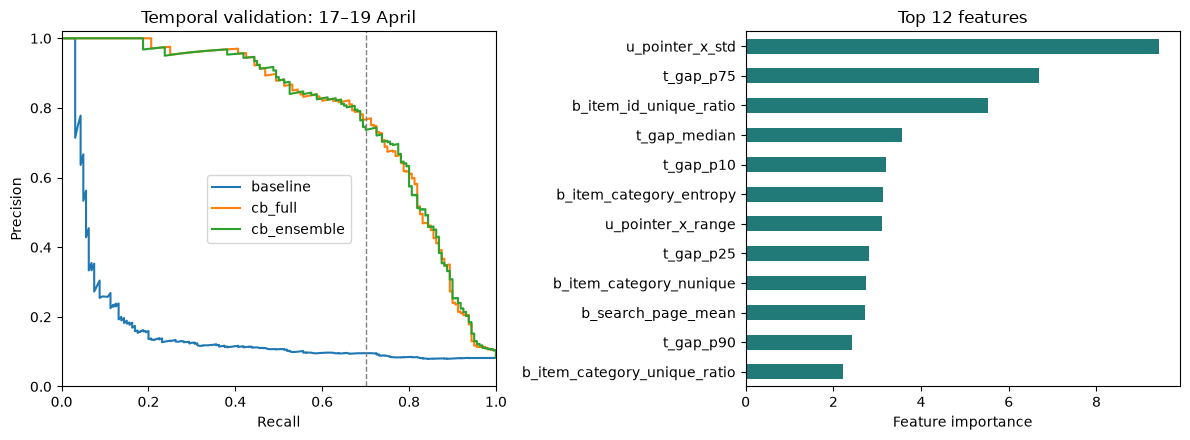

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
precision, recall = pr_curve(y_valid, baseline_score)
axes[0].plot(recall, precision, label="baseline")
precision, recall = pr_curve(y_valid, single_score)
axes[0].plot(recall, precision, label="cb_full")
precision, recall = pr_curve(y_valid, selected_score)
axes[0].plot(recall, precision, label="cb_ensemble")
axes[0].axvline(.7, color="grey", linestyle="--", linewidth=1)
axes[0].set(xlabel="Recall", ylabel="Precision", title="Temporal validation: 17–19 April",
            xlim=(0, 1), ylim=(0, 1.02))
axes[0].legend()

importance = pd.Series(np.mean(holdout_importances, axis=0), index=X_train.columns)
importance = importance.sort_values(ascending=False)
importance.head(12).sort_values().plot.barh(ax=axes[1], color="#217a78")
axes[1].set(xlabel="Feature importance", title="Top 12 features")
fig.tight_layout()
plt.show()

Обе версии CatBoost заметно лучше baseline. Справа показаны важности признаков, усреднённые по трём моделям. Они помогают понять, на что опирается модель, но не объясняют причины поведения и не показывают, повышает признак оценку бота или снижает её.

## 9. Финальное обучение

Обучим три CatBoost на всём train с теми же параметрами и seed. Для каждой cookie из test возьмём среднее трёх вероятностей и запишем его в `score`. В `submission.csv` будут только `cookie_id` и `score`, в исходном порядке test.

In [31]:
test_scores = []
for model_seed in model_seeds:
    params = catboost_params.copy()
    params["random_seed"] = model_seed
    model = CatBoostClassifier(**params, cat_features=category_columns)
    model.fit(X_train, y_train)
    test_scores.append(model.predict_proba(X_test)[:, 1])

score = np.mean(test_scores, axis=0)
submission = pd.DataFrame({"cookie_id": test["cookie_id"], "score": score})

assert len(submission) == len(test) and submission["cookie_id"].is_unique
assert submission["score"].notna().all() and submission["score"].between(0, 1).all()
submission.to_csv("submission.csv", index=False, float_format="%.12f", lineterminator="\n")
print("Сохранён submission.csv, строк:", len(submission))
display(submission.head())

Сохранён submission.csv, строк: 4909


,cookie_id,score
0,ck_315fb710a0e371e7,0.000700
1,ck_a76ee3b3e3e522fd,0.095636
2,ck_94c9a4d382689e82,0.047128
3,ck_8eaf9509ad9462a0,0.000723
4,ck_9a88a5a989cb5bc6,0.007008


## Итоги

Для модели собрали 118 признаков по событиям внутри окна каждой cookie. Они описывают действия, время, разнообразие объявлений и запросов, клиента, координаты и порядок действий. Точные дубли удалили, числовые пропуски заполнили значением -1. Категориальные признаки обрабатывает CatBoost, сами ID в обучение не попадают.

Среднее трёх CatBoost улучшило средний P@R≥70% на двух временных разбиениях с 0.6850 до 0.7071. На последних днях train результат вырос с 0.7778 до 0.8071. Этот блок уже использовался в экспериментах, поэтому независимой проверкой его не считаем.

Остаётся вопрос, как модель сработает на новых сервисах сбора данных. В разметке указаны известные сервисы, но их идентификаторов нет, поэтому отдельно проверить такой перенос не получилось. Среди cookie с меткой 0 также может быть неизвестная автоматизация. И ещё: в последнем блоке всего 160 ботов, так что небольшие изменения метрики могут быть случайными.

С написанием и исправлением кода помогал GPT-6 Astra через Codex, с thinking effort high. Основу решения и основные идеи я предложил сам, затем дорабатывал их вместе с моделью.